In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The dataset has no headers, so we define them manually.
# These are the official NSL-KDD column names from the documentation.
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load the training set
train_df = pd.read_csv('data/KDDTrain+.txt', names=columns)

# Load the test set
test_df = pd.read_csv('data/KDDTest+.txt', names=columns)

print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set:     {test_df.shape[0]} rows, {test_df.shape[1]} columns")


Training set: 125973 rows, 43 columns
Test set:     22544 rows, 43 columns


In [3]:
# Let's see what a single network connection record looks like
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# Check data types and non-null counts
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [5]:
# How many unique attack types are there?
print(f"Unique labels: {train_df['label'].nunique()}")
print()

# Count of each label, sorted
label_counts = train_df['label'].value_counts()
print(label_counts)

Unique labels: 23

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [6]:
# Normal vs Attack — the big picture
normal_count = train_df[train_df['label'] == 'normal'].shape[0]
attack_count = train_df[train_df['label'] != 'normal'].shape[0]

print(f"Normal: {normal_count} ({normal_count/len(train_df)*100:.1f}%)")
print(f"Attack: {attack_count} ({attack_count/len(train_df)*100:.1f}%)")

Normal: 67343 (53.5%)
Attack: 58630 (46.5%)


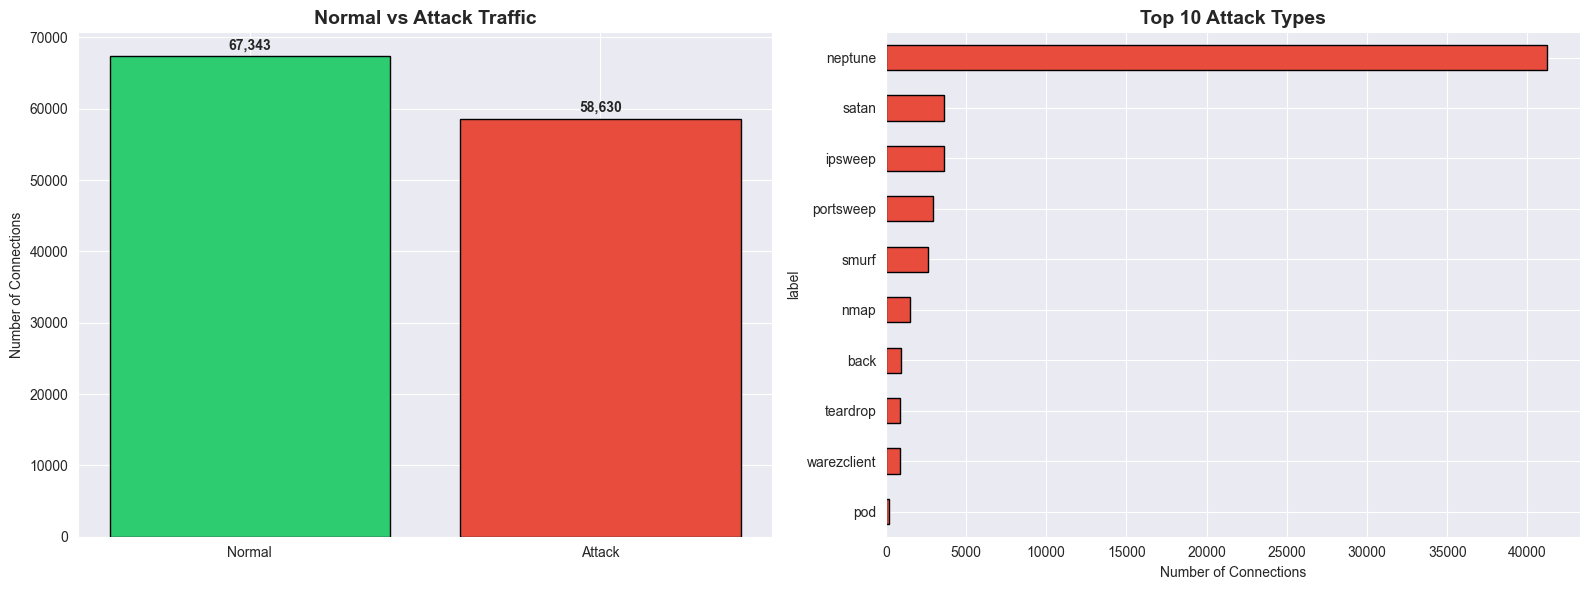

In [7]:
# Visualize the class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Normal vs Attack (binary)
labels = ['Normal', 'Attack']
sizes = [normal_count, attack_count]
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, sizes, color=colors, edgecolor='black')
axes[0].set_title('Normal vs Attack Traffic', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Connections')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Right plot: Top 10 specific attack types
top_attacks = train_df[train_df['label'] != 'normal']['label'].value_counts().head(10)
top_attacks.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 10 Attack Types', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Connections')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [8]:
# Map each attack to its category
# This mapping comes from the original KDD Cup 99 documentation

attack_map = {
    'normal': 'Normal',

    # DoS - Denial of Service: overwhelm the target so it can't serve real users
    'neptune': 'DoS', 'smurf': 'DoS', 'pod': 'DoS', 'teardrop': 'DoS',
    'land': 'DoS', 'back': 'DoS',

    # Probe - Surveillance/scanning: attacker is mapping your network
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe',

    # R2L - Remote to Local: attacker tries to gain local access from remote
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',

    # U2R - User to Root: attacker already has local access, tries to get root
    'buffer_overflow': 'U2R', 'rootkit': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
}

train_df['attack_category'] = train_df['label'].map(attack_map)
test_df['attack_category'] = test_df['label'].map(attack_map)

# Check for any unmapped labels (important for the test set which has extra attack types)
unmapped = test_df[test_df['attack_category'].isna()]['label'].unique()
print(f"Unmapped labels in test set: {unmapped}")
print()

# Category distribution
cat_counts = train_df['attack_category'].value_counts()
print(cat_counts)

Unmapped labels in test set: <StringArray>
[        'saint',         'mscan',       'apache2', 'snmpgetattack',
  'processtable',    'httptunnel',            'ps',     'snmpguess',
      'mailbomb',         'named',      'sendmail',         'xterm',
          'worm',         'xlock',        'xsnoop',     'sqlattack',
      'udpstorm']
Length: 17, dtype: str

attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


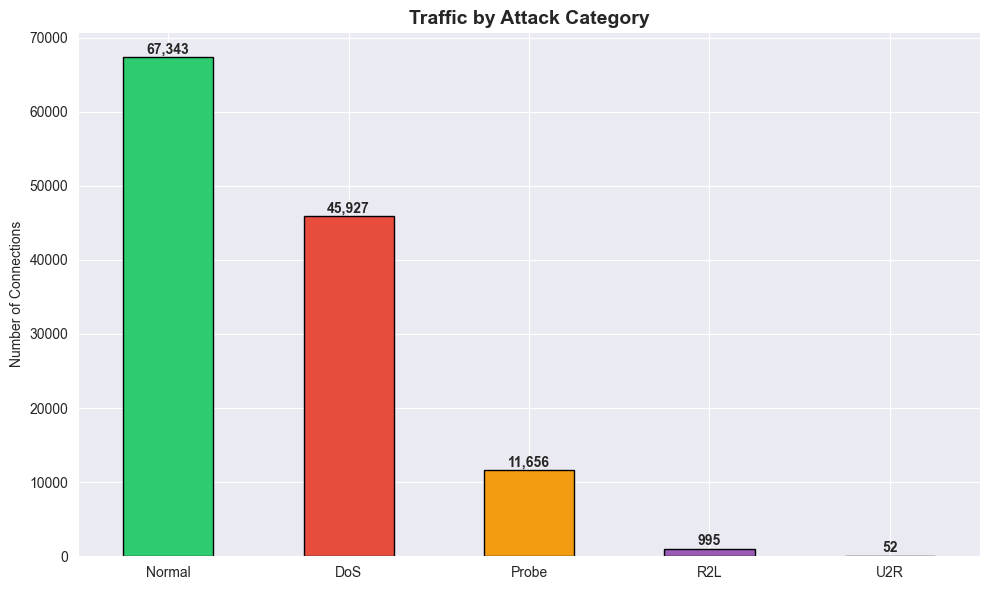

In [9]:
# Visualize attack categories
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Normal': '#2ecc71',
    'DoS': '#e74c3c',
    'Probe': '#f39c12',
    'R2L': '#9b59b6',
    'U2R': '#e91e63'
}

cat_counts.plot(
    kind='bar',
    color=[colors[cat] for cat in cat_counts.index],
    edgecolor='black',
    ax=ax
)
ax.set_title('Traffic by Attack Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Connections')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(cat_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Map the unknown test attacks to their correct categories
# These mappings come from the KDD Cup documentation

unknown_attack_map = {
    # DoS variants
    'apache2': 'DoS', 'mailbomb': 'DoS', 'processtable': 'DoS',
    'udpstorm': 'DoS',

    # Probe variants
    'saint': 'Probe', 'mscan': 'Probe',

    # R2L variants
    'snmpgetattack': 'R2L', 'snmpguess': 'R2L', 'httptunnel': 'R2L',
    'named': 'R2L', 'sendmail': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'worm': 'R2L',

    # U2R variants
    'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R',
}

# Apply to test set — fill the NaN values we found
test_df['attack_category'] = test_df['label'].map({**attack_map, **unknown_attack_map})

# Verify nothing is unmapped now
print(f"Remaining unmapped: {test_df['attack_category'].isna().sum()}")
print()

# Compare train vs test distribution
comparison = pd.DataFrame({
    'Train': train_df['attack_category'].value_counts(),
    'Test': test_df['attack_category'].value_counts()
})
comparison['Train %'] = (comparison['Train'] / len(train_df) * 100).round(1)
comparison['Test %'] = (comparison['Test'] / len(test_df) * 100).round(1)
print(comparison)

Remaining unmapped: 0

                 Train  Test  Train %  Test %
attack_category                              
DoS              45927  7458     36.5    33.1
Normal           67343  9711     53.5    43.1
Probe            11656  2421      9.3    10.7
R2L                995  2887      0.8    12.8
U2R                 52    67      0.0     0.3


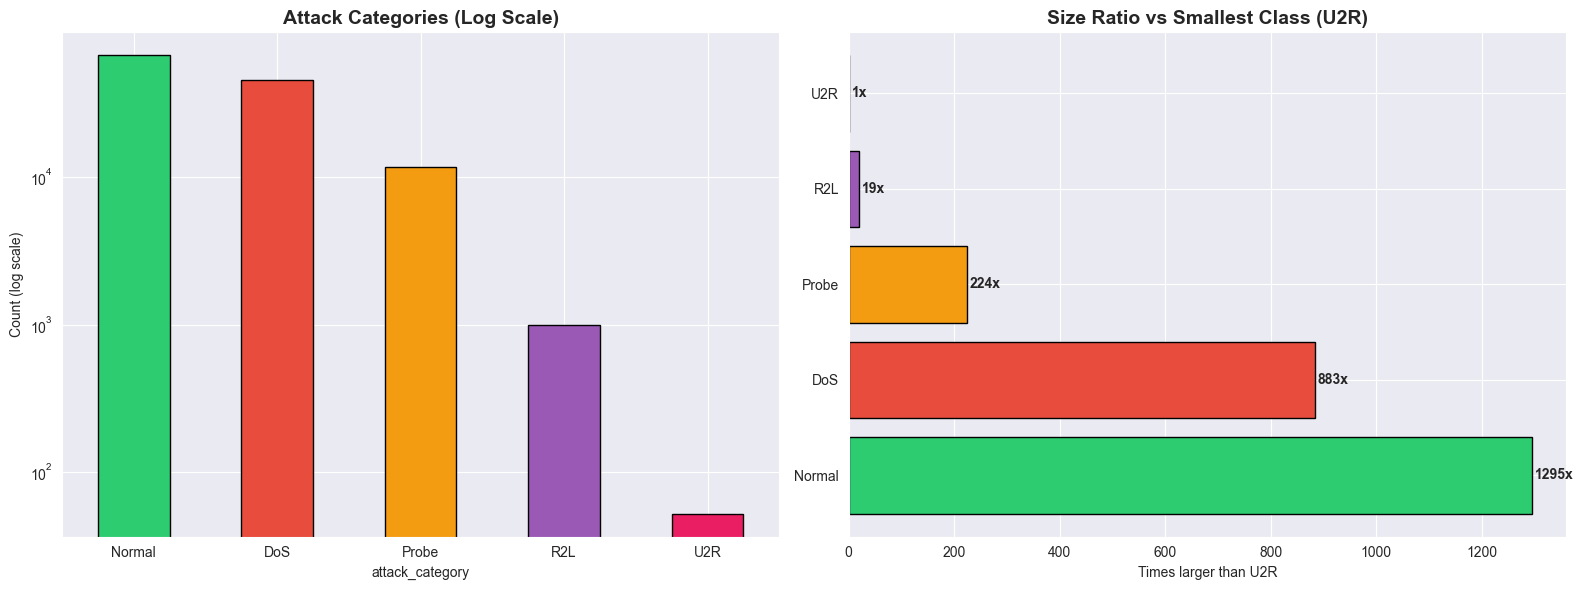

In [11]:
# The imbalance problem visualized — this is WHY Phase 4 exists
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute numbers (log scale to actually see U2R)
train_df['attack_category'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e91e63'],
    edgecolor='black', logy=True
)
axes[0].set_title('Attack Categories (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Right: show the ratio problem
categories = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
counts = [67343, 45927, 11656, 995, 52]
ratios = [c / min(counts) for c in counts]  # ratio compared to smallest class

bars = axes[1].barh(categories, ratios, color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e91e63'],
                     edgecolor='black')
axes[1].set_title('Size Ratio vs Smallest Class (U2R)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Times larger than U2R')

for bar, ratio in zip(bars, ratios):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{ratio:.0f}x', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

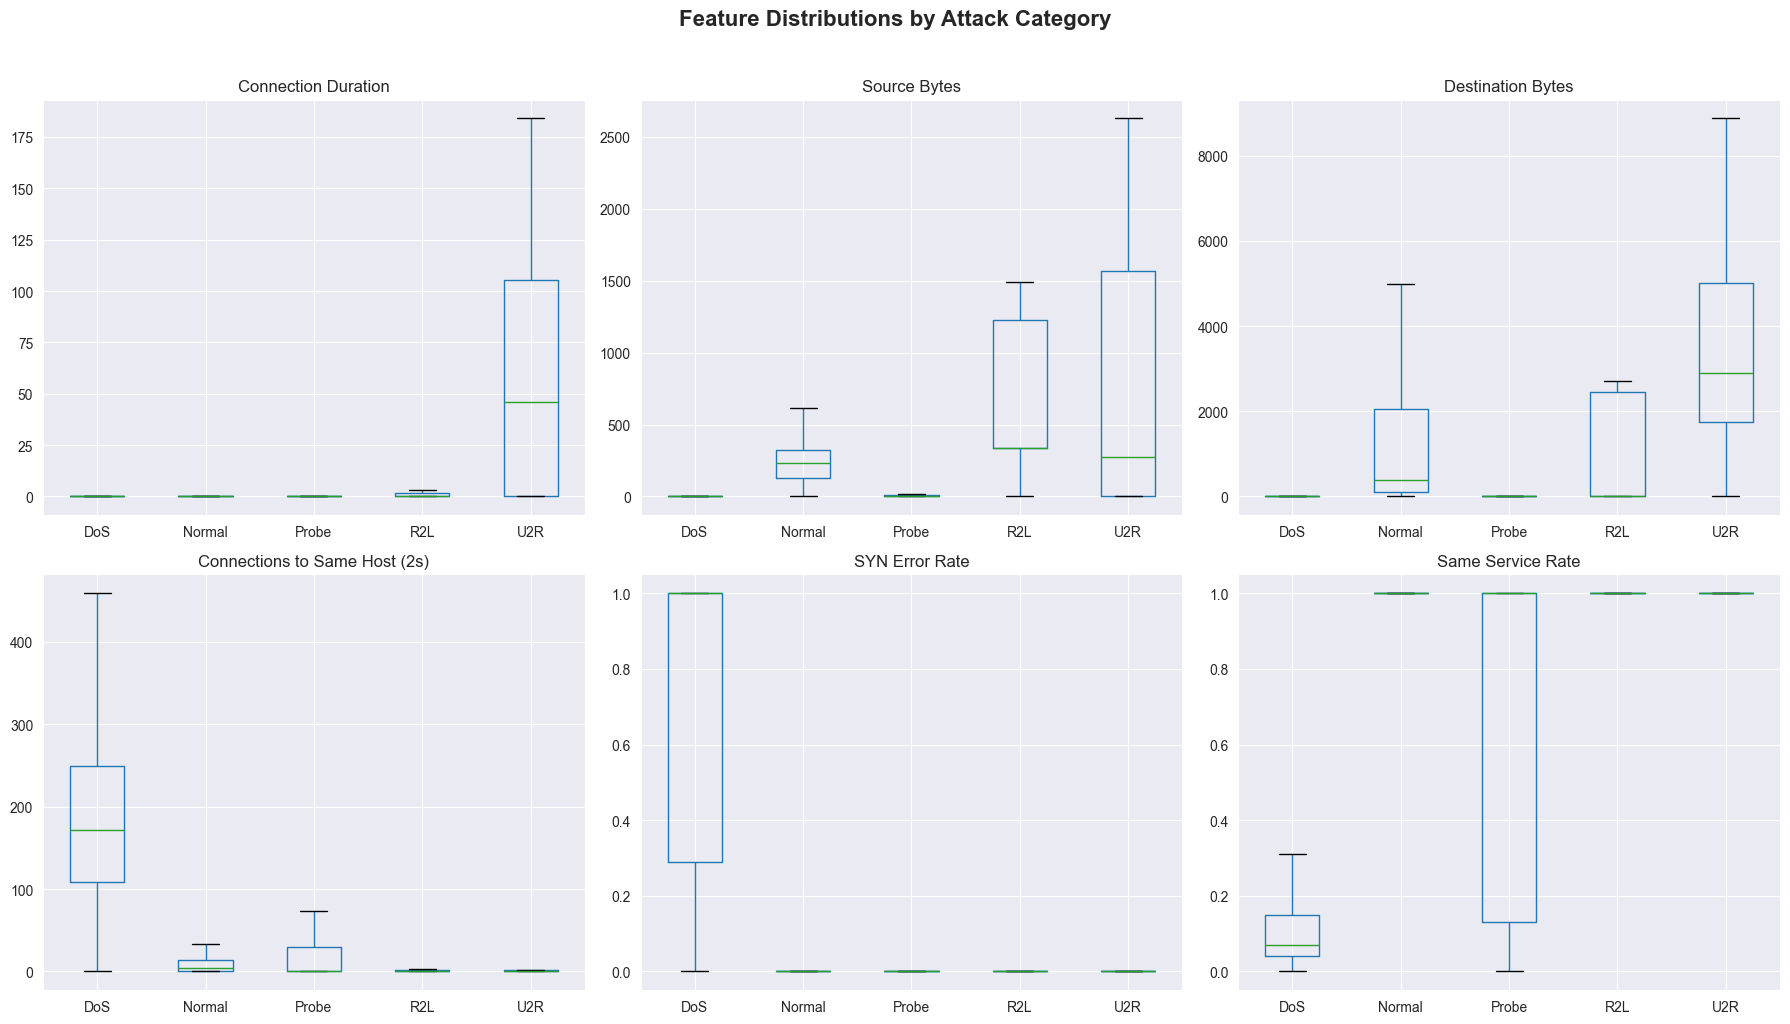

In [12]:
# Let's see how key features differ between Normal and Attack traffic
# Picking features that are intuitive from a networking perspective

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Duration of connection
train_df.boxplot(column='duration', by='attack_category', ax=axes[0, 0],
                 showfliers=False)  # hide outliers for readability
axes[0, 0].set_title('Connection Duration')
axes[0, 0].set_xlabel('')

# 2. Source bytes sent
train_df.boxplot(column='src_bytes', by='attack_category', ax=axes[0, 1],
                 showfliers=False)
axes[0, 1].set_title('Source Bytes')
axes[0, 1].set_xlabel('')

# 3. Destination bytes received
train_df.boxplot(column='dst_bytes', by='attack_category', ax=axes[0, 2],
                 showfliers=False)
axes[0, 2].set_title('Destination Bytes')
axes[0, 2].set_xlabel('')

# 4. Count (connections to same host in last 2 seconds)
train_df.boxplot(column='count', by='attack_category', ax=axes[1, 0],
                 showfliers=False)
axes[1, 0].set_title('Connections to Same Host (2s)')
axes[1, 0].set_xlabel('')

# 5. SYN error rate
train_df.boxplot(column='serror_rate', by='attack_category', ax=axes[1, 1],
                 showfliers=False)
axes[1, 1].set_title('SYN Error Rate')
axes[1, 1].set_xlabel('')

# 6. Same service rate
train_df.boxplot(column='same_srv_rate', by='attack_category', ax=axes[1, 2],
                 showfliers=False)
axes[1, 2].set_title('Same Service Rate')
axes[1, 2].set_xlabel('')

plt.suptitle('Feature Distributions by Attack Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Protocol distribution per category (%):
protocol_type    icmp    tcp   udp
attack_category                   
DoS               6.2   91.9   1.9
Normal            1.9   79.6  18.5
Probe            35.5   50.2  14.3
R2L               0.0  100.0   0.0
U2R               0.0   94.2   5.8



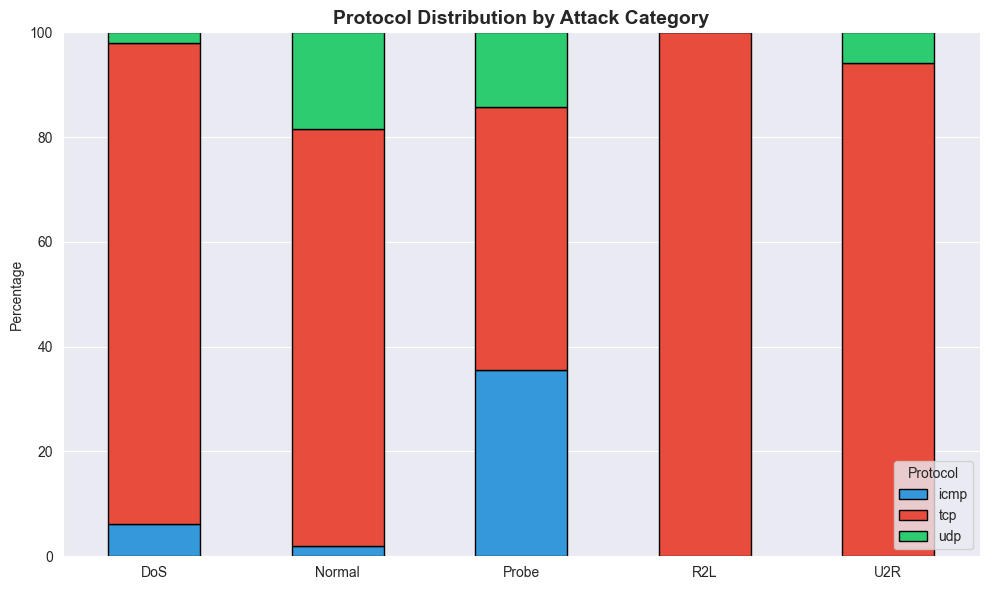

In [13]:
# Protocol distribution per attack category
protocol_by_category = pd.crosstab(
    train_df['attack_category'],
    train_df['protocol_type'],
    normalize='index'
) * 100

print("Protocol distribution per category (%):")
print(protocol_by_category.round(1))
print()

# Visualize it
protocol_by_category.plot(
    kind='bar', stacked=True, figsize=(10, 6),
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='black'
)
plt.title('Protocol Distribution by Attack Category', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.xlabel('')
plt.legend(title='Protocol')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Save the dataframes with the attack_category column for Phase 2
train_df.to_csv('data/train_processed_phase1.csv', index=False)
test_df.to_csv('data/test_processed_phase1.csv', index=False)
print("Phase 1 complete — data saved!")

Phase 1 complete — data saved!
